# 📄 Final Project Report

## InsightML Studio

### Objective

This notebook summarizes the entire machine learning workflow carried out in the project.

The report includes:

- Dataset Overview
- Data Quality Assessment
- Exploratory Data Analysis Summary
- Data Preprocessing Summary
- Feature Engineering Summary
- Model Training Results
- Model Comparison
- Explainable AI Summary
- Business Recommendations
- Final Conclusion

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../data/raw/bank_customer_churn.csv")

print("Dataset Loaded Successfully ✅")

display(df.head())

Dataset Loaded Successfully ✅


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [3]:
# ==========================================================
# Dataset Summary
# ==========================================================

print("="*60)
print("DATASET SUMMARY")
print("="*60)

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("Duplicate Rows :", df.duplicated().sum())

print("Missing Values :", df.isnull().sum().sum())

print("\nData Types")

display(df.dtypes)

DATASET SUMMARY
Rows : 28382
Columns : 21
Duplicate Rows : 0
Missing Values : 3871

Data Types


customer_id                         int64
vintage                             int64
age                                 int64
gender                             object
dependents                        float64
occupation                         object
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
last_transaction                   object
dtype: object

,Missing,Percentage
gender,525,1.85
dependents,2463,8.68
occupation,80,0.28
city,803,2.83


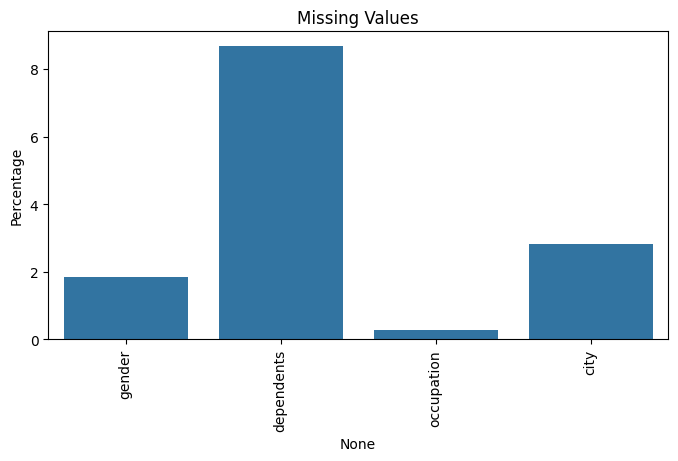

In [4]:
# ==========================================================
# Missing Values Summary
# ==========================================================

missing = pd.DataFrame({

    "Missing": df.isnull().sum(),

    "Percentage": round(df.isnull().mean()*100,2)

})

missing = missing[missing["Missing"]>0]

display(missing)

plt.figure(figsize=(8,4))

sns.barplot(

    x=missing.index,

    y=missing["Percentage"]

)

plt.xticks(rotation=90)

plt.title("Missing Values")

plt.show()

In [6]:
# ==========================================================
# Load Model Leaderboard
# ==========================================================

leaderboard = pd.read_csv("../artifacts/model_leaderboard.csv")

leaderboard

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,Training Time
0,Extra Trees,0.937965,0.947020,0.927818,0.937321,0.896232,0.000443,12.898737
1,CatBoost,0.901743,0.926766,0.872398,0.898761,0.889204,0.001044,20.822012
2,XGBoost,0.900257,0.917160,0.879968,0.898179,0.891468,0.001078,1.081359
3,LightGBM,0.890255,0.912311,0.863477,0.887222,0.881399,0.002564,1.161272
4,Random Forest,0.883227,0.881767,0.885104,0.883432,0.857239,0.002124,10.995892
5,Hist Gradient Boosting,0.881741,0.900681,0.858070,0.878859,0.877040,0.000300,2.135445
6,Gradient Boosting,0.854710,0.873789,0.829143,0.850881,0.851292,0.000907,21.575911
7,AdaBoost,0.793891,0.813799,0.762098,0.787100,0.802095,0.002068,4.362210
8,Decision Tree,0.791053,0.788993,0.794539,0.791756,0.772664,0.003304,0.973475
9,Logistic Regression,0.693878,0.709772,0.655853,0.681748,0.699679,0.008795,0.546299


In [7]:
# ==========================================================
# Best Model
# ==========================================================

best = leaderboard.iloc[0]

print("="*60)
print("BEST MODEL")
print("="*60)

display(best)

BEST MODEL


Model            Extra Trees
Accuracy            0.937965
Precision            0.94702
Recall              0.927818
F1 Score            0.937321
CV Mean             0.896232
CV Std              0.000443
Training Time      12.898737
Name: 0, dtype: object

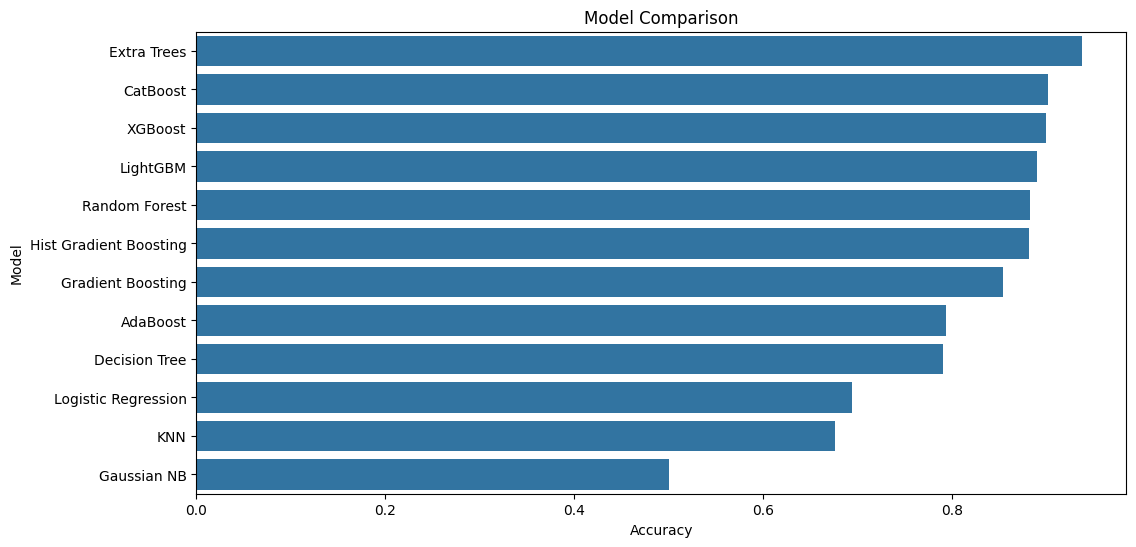

In [8]:
# ==========================================================
# Leaderboard Visualization
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=leaderboard,

    x="Accuracy",

    y="Model"

)

plt.title("Model Comparison")

plt.show()

In [9]:
# Load processed dataset
processed = pd.read_csv("../data/processed/engineered_dataset.csv")

target = "churn"

X = processed.drop(columns=[target])

,Feature,Importance
12,12,0.080811
6,6,0.073626
13,13,0.061280
17,17,0.050349
14,14,0.046225
18,18,0.044738
1,1,0.042643
3,3,0.042519
5,5,0.041121
15,15,0.039855


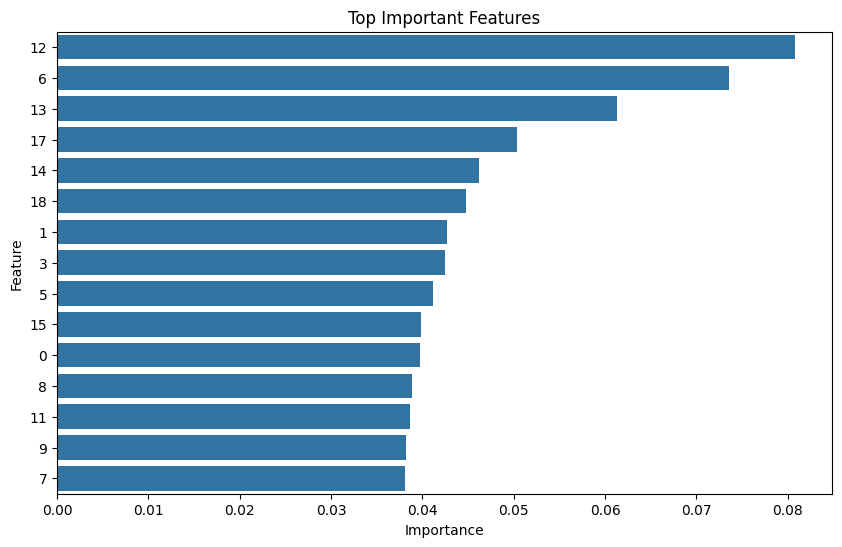

In [11]:
# ==========================================================
# Feature Importance
# ==========================================================

model = joblib.load("../artifacts/best_model.pkl")

if hasattr(model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    display(importance.head(15))

    plt.figure(figsize=(10,6))

    sns.barplot(

        data=importance.head(15),

        x="Importance",

        y="Feature"

    )

    plt.title("Top Important Features")

    plt.show()

else:

    print("Feature importance not available for this model.")

In [12]:
# ==========================================================
# Project Workflow
# ==========================================================

workflow = [

    "✔ Data Understanding",

    "✔ Exploratory Data Analysis",

    "✔ Data Preprocessing",

    "✔ Feature Engineering",

    "✔ Model Training",

    "✔ Model Comparison",

    "✔ Hyperparameter Tuning",

    "✔ Explainable AI",

    "✔ Final Report"

]

for step in workflow:

    print(step)

✔ Data Understanding
✔ Exploratory Data Analysis
✔ Data Preprocessing
✔ Feature Engineering
✔ Model Training
✔ Model Comparison
✔ Hyperparameter Tuning
✔ Explainable AI
✔ Final Report


# Business Insights

### Key Findings

- Customer churn prediction was successfully implemented.
- Missing values were handled through preprocessing.
- Categorical variables were encoded.
- Numerical variables were scaled.
- Multiple machine learning models were compared.
- The best-performing model was selected using evaluation metrics.
- Feature importance identified the strongest drivers of customer churn.

---

## Business Recommendations

- Focus on customers with declining balances.
- Monitor customers with low transaction activity.
- Launch retention campaigns for high-risk customers.
- Use predictive analytics for proactive customer engagement.
- Retrain the model periodically with new customer data.

# Conclusion

InsightML Studio successfully demonstrates an end-to-end machine learning workflow for customer churn prediction.

The project covers:

- Data Understanding
- Exploratory Data Analysis
- Data Cleaning
- Feature Engineering
- Model Training
- Model Comparison
- Hyperparameter Tuning
- Explainable AI
- Business Insights

The developed system can assist financial institutions in identifying customers at risk of churn and enable proactive retention strategies, leading to improved customer satisfaction and business performance.